In [1]:
import pandas as pd
import numpy as np

In [2]:
feature_data = pd.read_csv(
    "../data/processed/feature_data.csv"
)

In [3]:
feature_data.head()

,Customer_ID,Age,City,State,Income_Bracket,Registration_Year,total_transactions,total_spent,average_purchase,total_sessions,total_pages_visited,total_earned_points,total_redeemed_points
0,C100000,56,Pune,Gujarat,Medium,2025,0.0,0.0,0.0,2.0,36.0,85.0,395.0
1,C100001,46,Nagpur,West Bengal,Low,2025,1.0,3288.0,3288.0,1.0,11.0,1324.0,522.0
2,C100002,32,Kolkata,Rajasthan,High,2022,0.0,0.0,0.0,2.0,32.0,0.0,0.0
3,C100003,25,Nagpur,Karnataka,High,2025,1.0,2048.0,2048.0,1.0,12.0,2399.0,676.0
4,C100004,38,Pune,Tamil Nadu,Medium,2022,1.0,234.0,234.0,1.0,13.0,1350.0,595.0


In [4]:
print("Shape:", feature_data.shape)

Shape: (25000, 13)


In [5]:
print(feature_data.columns.tolist())

['Customer_ID', 'Age', 'City', 'State', 'Income_Bracket', 'Registration_Year', 'total_transactions', 'total_spent', 'average_purchase', 'total_sessions', 'total_pages_visited', 'total_earned_points', 'total_redeemed_points']


In [6]:
feature_data.isnull().sum()

Customer_ID              0
Age                      0
City                     0
State                    0
Income_Bracket           0
Registration_Year        0
total_transactions       0
total_spent              0
average_purchase         0
total_sessions           0
total_pages_visited      0
total_earned_points      0
total_redeemed_points    0
dtype: int64

In [7]:
print(
    "Customers with transactions:",
    (feature_data['total_transactions'] > 0).sum()
)

print(
    "Customers without transactions:",
    (feature_data['total_transactions'] == 0).sum()
)

Customers with transactions: 15818
Customers without transactions: 9182


In [8]:
feature_data['Churn'] = np.where(
    feature_data['total_transactions'] == 0,
    1,
    0
)

In [9]:
feature_data['Churn'].value_counts()

Churn
0    15818
1     9182
Name: count, dtype: int64

In [10]:
print(
    feature_data['Churn'].value_counts(normalize=True) * 100
)

Churn
0    63.272
1    36.728
Name: proportion, dtype: float64


In [11]:
feature_data[['Customer_ID', 'total_transactions', 'Churn']].head(10)

,Customer_ID,total_transactions,Churn
0,C100000,0.0,1
1,C100001,1.0,0
2,C100002,0.0,1
3,C100003,1.0,0
4,C100004,1.0,0
5,C100005,3.0,0
6,C100006,0.0,1
7,C100007,1.0,0
8,C100008,0.0,1
9,C100009,3.0,0


In [12]:
features = [
    'Age',
    'Income_Bracket',
    'Registration_Year',
    'total_transactions',
    'total_spent',
    'average_purchase',
    'total_sessions',
    'total_pages_visited',
    'total_earned_points',
    'total_redeemed_points'
]

In [13]:
X = feature_data[features]
y = feature_data['Churn']

In [14]:
X.head()

,Age,Income_Bracket,Registration_Year,total_transactions,total_spent,average_purchase,total_sessions,total_pages_visited,total_earned_points,total_redeemed_points
0,56,Medium,2025,0.0,0.0,0.0,2.0,36.0,85.0,395.0
1,46,Low,2025,1.0,3288.0,3288.0,1.0,11.0,1324.0,522.0
2,32,High,2022,0.0,0.0,0.0,2.0,32.0,0.0,0.0
3,25,High,2025,1.0,2048.0,2048.0,1.0,12.0,2399.0,676.0
4,38,Medium,2022,1.0,234.0,234.0,1.0,13.0,1350.0,595.0


In [15]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Churn, dtype: int64

In [16]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (25000, 10)
y Shape: (25000,)


In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    25000 non-null  int64  
 1   Income_Bracket         25000 non-null  object 
 2   Registration_Year      25000 non-null  int64  
 3   total_transactions     25000 non-null  float64
 4   total_spent            25000 non-null  float64
 5   average_purchase       25000 non-null  float64
 6   total_sessions         25000 non-null  float64
 7   total_pages_visited    25000 non-null  float64
 8   total_earned_points    25000 non-null  float64
 9   total_redeemed_points  25000 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 1.9+ MB


In [18]:
print(y.value_counts())

Churn
0    15818
1     9182
Name: count, dtype: int64


In [19]:
print(X['Income_Bracket'].unique())

['Medium' 'Low' 'High']


In [20]:
X = pd.get_dummies(
    X,
    columns=['Income_Bracket'],
    drop_first=True
)

In [21]:
X.head()

,Age,Registration_Year,total_transactions,total_spent,average_purchase,total_sessions,total_pages_visited,total_earned_points,total_redeemed_points,Income_Bracket_Low,Income_Bracket_Medium
0,56,2025,0.0,0.0,0.0,2.0,36.0,85.0,395.0,False,True
1,46,2025,1.0,3288.0,3288.0,1.0,11.0,1324.0,522.0,True,False
2,32,2022,0.0,0.0,0.0,2.0,32.0,0.0,0.0,False,False
3,25,2025,1.0,2048.0,2048.0,1.0,12.0,2399.0,676.0,False,False
4,38,2022,1.0,234.0,234.0,1.0,13.0,1350.0,595.0,False,True


In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    25000 non-null  int64  
 1   Registration_Year      25000 non-null  int64  
 2   total_transactions     25000 non-null  float64
 3   total_spent            25000 non-null  float64
 4   average_purchase       25000 non-null  float64
 5   total_sessions         25000 non-null  float64
 6   total_pages_visited    25000 non-null  float64
 7   total_earned_points    25000 non-null  float64
 8   total_redeemed_points  25000 non-null  float64
 9   Income_Bracket_Low     25000 non-null  bool   
 10  Income_Bracket_Medium  25000 non-null  bool   
dtypes: bool(2), float64(7), int64(2)
memory usage: 1.8 MB


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (20000, 11)
X_test: (5000, 11)
y_train: (20000,)
y_test: (5000,)


In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
churn_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [27]:
churn_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
y_pred = churn_model.predict(X_test)

In [29]:
print(y_pred[:10])

[1 1 0 0 0 0 0 0 0 1]


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [32]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 1.0


In [33]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 1.0


In [34]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 1.0


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3164
           1       1.00      1.00      1.00      1836

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



In [36]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3164    0]
 [   0 1836]]


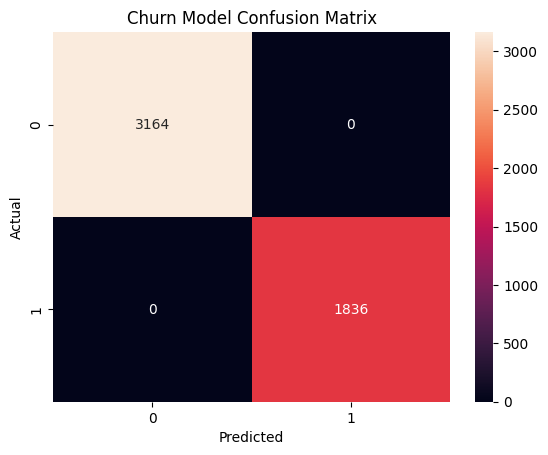

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Churn Model Confusion Matrix")
plt.show()

In [38]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': churn_model.feature_importances_
})

feature_importance

,Feature,Importance
0,Age,0.000015
1,Registration_Year,0.000046
2,total_transactions,0.338636
3,total_spent,0.372013
4,average_purchase,0.289035
5,total_sessions,0.000011
6,total_pages_visited,0.000076
7,total_earned_points,0.000091
8,total_redeemed_points,0.000054
9,Income_Bracket_Low,0.000026


In [39]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
3,total_spent,0.372013
2,total_transactions,0.338636
4,average_purchase,0.289035
7,total_earned_points,0.000091
6,total_pages_visited,0.000076
8,total_redeemed_points,0.000054
1,Registration_Year,0.000046
9,Income_Bracket_Low,0.000026
0,Age,0.000015
5,total_sessions,0.000011


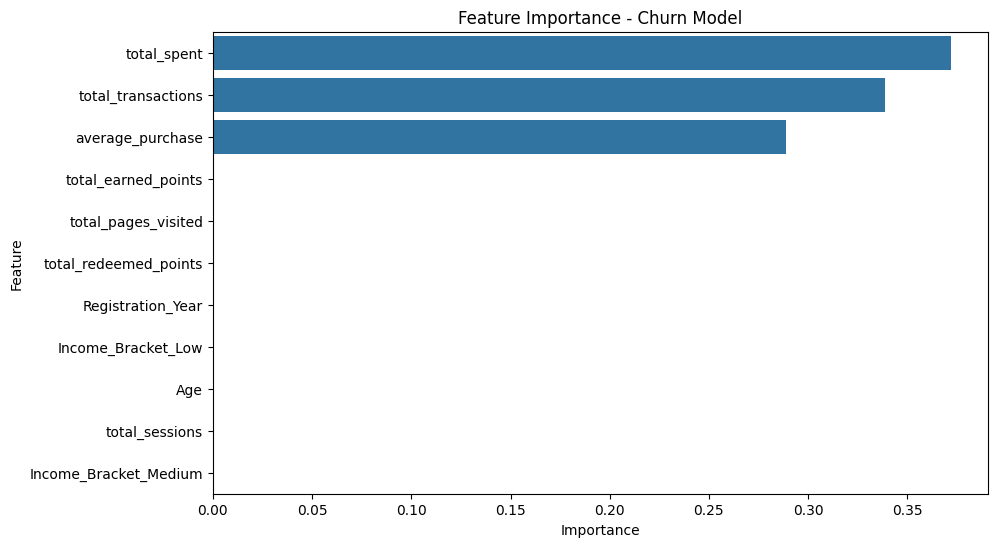

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance - Churn Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [41]:
feature_importance.to_csv(
    "../data/processed/churn_feature_importance.csv",
    index=False
)

In [42]:
import joblib

In [43]:
joblib.dump(
    churn_model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']